<a href="https://colab.research.google.com/github/Nashvillle/Project.exe/blob/main/MiniProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [2]:
df = pd.read_csv("/content/MentalHealthSurvey_augmented_300.csv")
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

df.head()


Dataset Shape: (387, 21)

Columns:
Index(['gender', 'age', 'university', 'degree_level', 'degree_major',
       'academic_year', 'cgpa', 'residential_status', 'campus_discrimination',
       'sports_engagement', 'average_sleep', 'study_satisfaction',
       'academic_workload ', 'academic_pressure', 'financial_concerns',
       'social_relationships', 'depression', 'anxiety', 'isolation',
       'future_insecurity', 'stress_relief_activities'],
      dtype='object')


,gender,age,university,degree_level,degree_major,academic_year,cgpa,residential_status,campus_discrimination,sports_engagement,...,study_satisfaction,academic_workload,academic_pressure,financial_concerns,social_relationships,depression,anxiety,isolation,future_insecurity,stress_relief_activities
0,Male,20,PU,Undergraduate,Data Science,2nd year,3.0-3.5,Off-Campus,No,No Sports,...,5,4,5,4,3,2,1,1,2,"Religious Activities, Social Connections, Onli..."
1,Male,20,UET,Postgraduate,Computer Science,3rd year,3.0-3.5,Off-Campus,No,1-3 times,...,5,4,4,1,3,3,3,3,4,Online Entertainment
2,Male,20,FAST,Undergraduate,Computer Science,3rd year,2.5-3.0,Off-Campus,No,1-3 times,...,5,5,5,3,4,2,3,3,1,"Religious Activities, Sports and Fitness, Onli..."
3,Male,20,UET,Undergraduate,Computer Science,3rd year,2.5-3.0,On-Campus,No,No Sports,...,3,5,4,4,1,5,5,5,3,Online Entertainment
4,Female,20,UET,Undergraduate,Computer Science,3rd year,3.0-3.5,Off-Campus,Yes,No Sports,...,3,5,5,2,3,5,5,4,4,Online Entertainment


In [3]:
# Remove extra spaces in column names (just in case)
df.columns = df.columns.str.strip()

# Check missing values
print(df.isnull().sum())


gender                      0
age                         0
university                  0
degree_level                0
degree_major                0
academic_year               0
cgpa                        0
residential_status          0
campus_discrimination       0
sports_engagement           0
average_sleep               0
study_satisfaction          0
academic_workload           0
academic_pressure           0
financial_concerns          0
social_relationships        0
depression                  0
anxiety                     0
isolation                   0
future_insecurity           0
stress_relief_activities    0
dtype: int64


In [4]:
# Convert sleep ranges to numeric values
import re

def convert_sleep(value):
    if isinstance(value, str):
        numbers = re.findall(r'\d+', value)
        if len(numbers) == 2:
            return (int(numbers[0]) + int(numbers[1])) / 2
    return value

df["average_sleep"] = df["average_sleep"].apply(convert_sleep)
df["average_sleep"] = pd.to_numeric(df["average_sleep"])

print(df["average_sleep"].unique())


[5.  3.  7.5]


In [5]:
#Depression Risk Category
def categorize_depression(score):
    if score <= 2:
        return "Low"
    elif score == 3:
        return "Medium"
    else:
        return "High"

df["depression_risk"] = df["depression"].apply(categorize_depression)

df["depression_risk"].value_counts()


,count
depression_risk,
High,165
Low,133
Medium,89


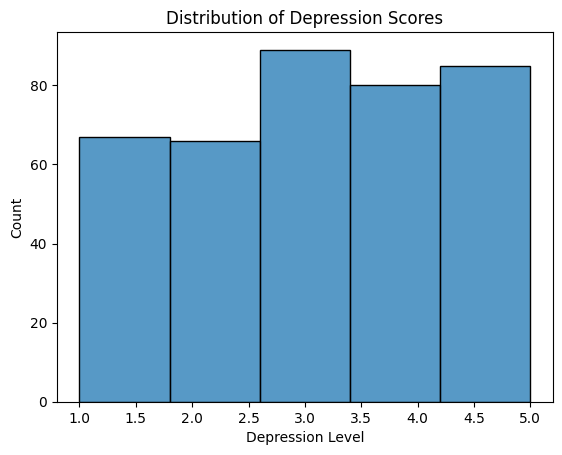

In [6]:
#Depression Count
plt.figure()
sns.histplot(df["depression"], bins=5)
plt.title("Distribution of Depression Scores")
plt.xlabel("Depression Level")
plt.ylabel("Count")
plt.show()


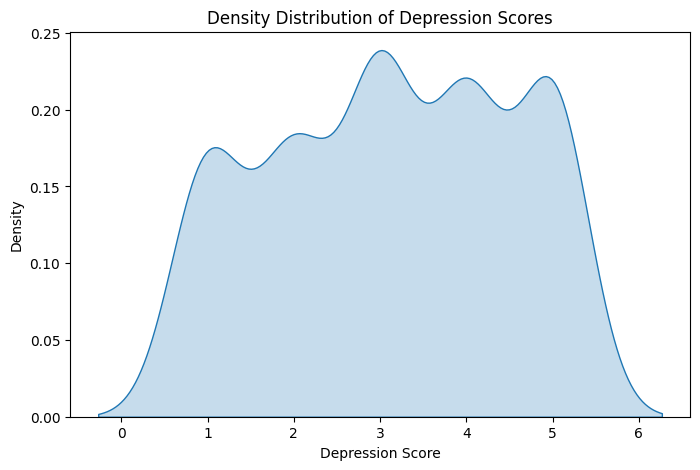

In [18]:
#Density Distribution of Depression Scores (KDE Plot)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.kdeplot(df['depression'], fill=True)

plt.title("Density Distribution of Depression Scores")
plt.xlabel("Depression Score")
plt.ylabel("Density")
plt.show()


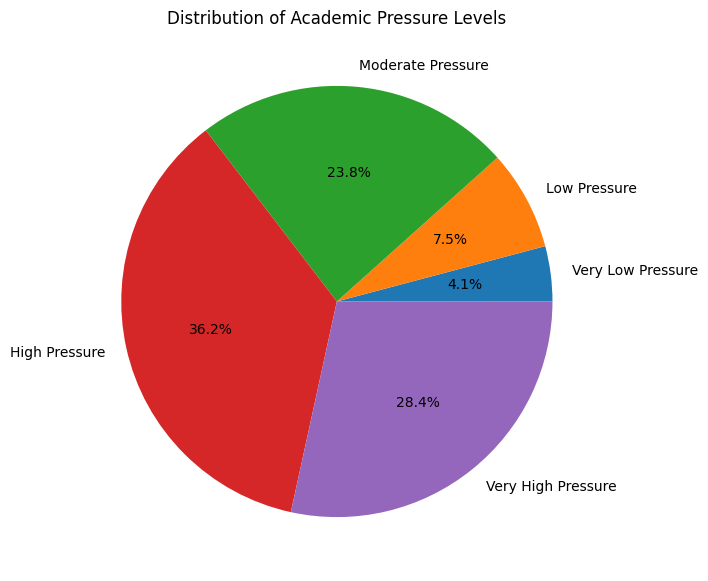

In [17]:
#Disturbution of Academic Pressure
import matplotlib.pyplot as plt

pressure_counts = df['academic_pressure'].value_counts().sort_index()

pressure_labels = {
    1: "Very Low Pressure",
    2: "Low Pressure",
    3: "Moderate Pressure",
    4: "High Pressure",
    5: "Very High Pressure"
}

named_pressure_labels = [pressure_labels[i] for i in pressure_counts.index]

plt.figure(figsize=(7,7))
plt.pie(pressure_counts, labels=named_pressure_labels, autopct='%1.1f%%')
plt.title("Distribution of Academic Pressure Levels")
plt.show()

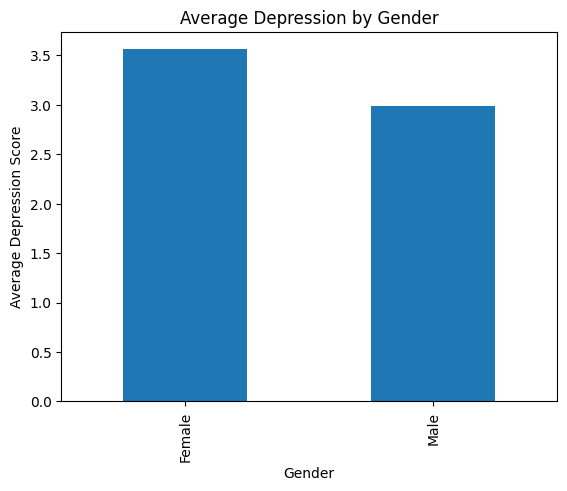

In [19]:
#Gender vs Mental Health (Whether males or females show higher average depression.)
gender_depression = df.groupby('gender')['depression'].mean()

plt.figure()
gender_depression.plot(kind='bar')
plt.title("Average Depression by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Depression Score")
plt.show()

In [8]:
#Define Features and Target
features = [
    "academic_pressure",
    "financial_concerns",
    "average_sleep",
    "study_satisfaction"
]

X = df[features]
y = df["depression_risk"]


In [9]:
#Encode Target Variable
le = LabelEncoder()
y = le.fit_transform(y)

print("Encoded Classes:", le.classes_)


Encoded Classes: ['High' 'Low' 'Medium']


In [10]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)


Training size: (309, 4)
Testing size: (78, 4)


In [11]:
#Train Random Forest Model
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)


RandomForestClassifier(max_depth=5, random_state=42)

In [14]:
#Make predicition
y_pred = model.predict(X_test)


In [13]:
#Evaluate Model
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.7307692307692307

Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.83      0.80        36
           1       0.67      0.79      0.72        28
           2       0.83      0.36      0.50        14

    accuracy                           0.73        78
   macro avg       0.76      0.66      0.67        78
weighted avg       0.74      0.73      0.72        78


Confusion Matrix:

[[30  5  1]
 [ 6 22  0]
 [ 3  6  5]]


In [15]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)


RandomForestClassifier(max_depth=5, random_state=42)

              Feature  Importance
1  financial_concerns    0.423951
0   academic_pressure    0.330280
3  study_satisfaction    0.149172
2       average_sleep    0.096598


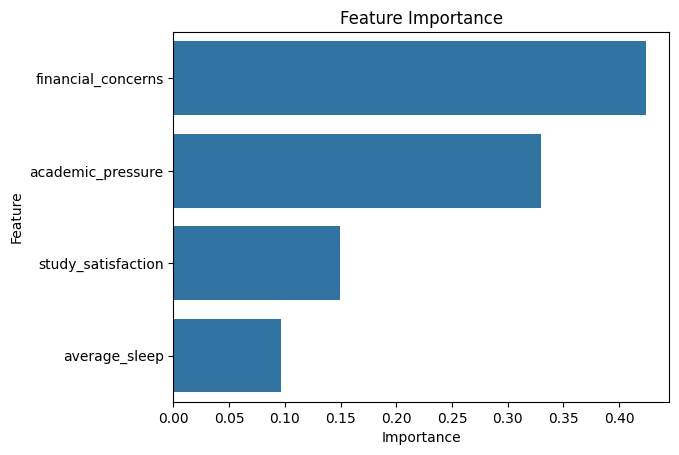

In [16]:
#Which feature influenced prediction most.
importances = model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feature_importance_df)

plt.figure()
sns.barplot(x="Importance", y="Feature", data=feature_importance_df)
plt.title("Feature Importance")
plt.show()
